In [1]:
packages <- c("ggplot2", "dplyr", "patchwork", "tidyr")
for (pkg in packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                pkg,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}
source("../../../utils/r_themes.r")

In [2]:
intensity_features_file_path <- file.path(
    "../../../1.ground_truth/data/0.ground_truth/annexinv_intensity_features_df.parquet"
)
figure_file_path <- file.path(
    "../figures/linearity_plot.png"
)
if (!file.exists(figure_file_path)) {
    dir.create(dirname(figure_file_path), recursive = TRUE)
}
# Read the intensity features
intensity_features_df <- arrow::read_parquet(intensity_features_file_path)
# tidy long
intensity_features_df <- intensity_features_df %>%
    pivot_longer(
        cols = colnames(intensity_features_df)[-1],
        names_to = "feature",
        values_to = "value"
    )

# select only annexin features 
intensity_features_df$channel <- gsub("Intensity_", "", intensity_features_df$feature)
intensity_features_df$channel <- sub(".*_(.*)", "\\1", intensity_features_df$feature)
intensity_features_df <- intensity_features_df %>% filter(
    channel == "AnnexinV"
)

# get only Intensity_MeanIntensity_AnnexinV feature
intensity_features_df <- intensity_features_df %>% filter(
    feature == "Intensity_MeanIntensity_AnnexinV"
)


Call:
lm(formula = value ~ Metadata_dose_num, data = intensity_features_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.7769 -0.8954  0.0070  0.9826  2.7224 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -0.033411   0.150904  -0.221    0.825    
Metadata_dose_num  0.014993   0.002653   5.651 1.18e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.375 on 115 degrees of freedom
Multiple R-squared:  0.2173,	Adjusted R-squared:  0.2105 
F-statistic: 31.93 on 1 and 115 DF,  p-value: 1.178e-07


Warning message in geom_violin(aes(group = Metadata_dose_num), width = 3, outlier.size = 0.5, :
“Ignoring unknown parameters: `outlier.size` and `outlier.colour`”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”


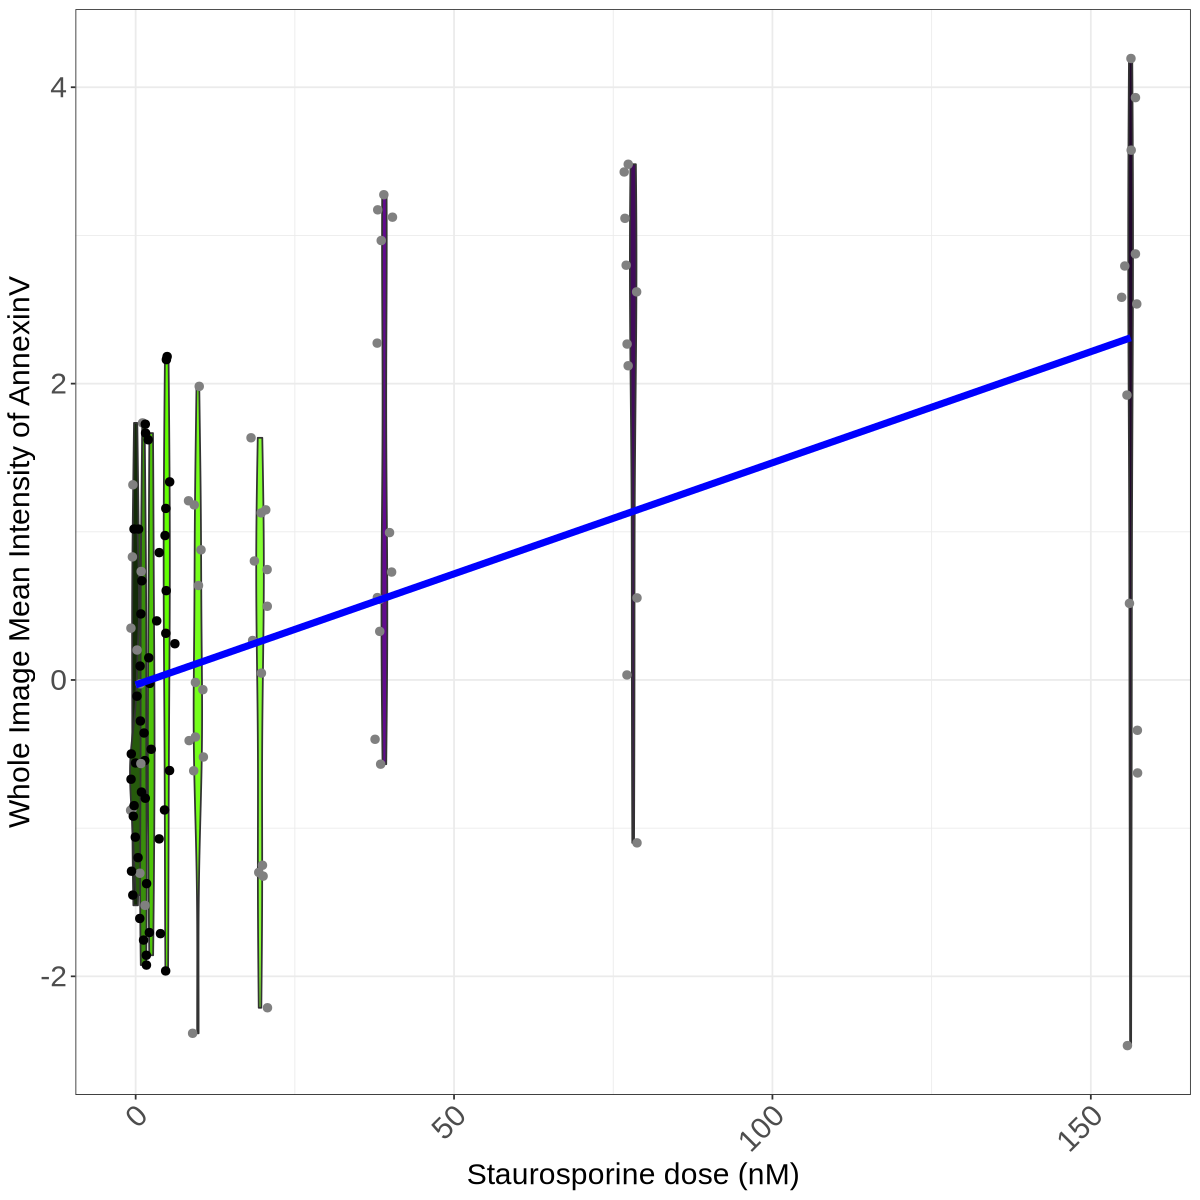

In [3]:
# --- 1. Numeric dose for regression ---
intensity_features_df$Metadata_dose_num <- as.numeric(as.character(intensity_features_df$Metadata_dose))

# --- 2. Fit linear model ---
lm_result <- lm(value ~ Metadata_dose_num, data = intensity_features_df)
summary(lm_result)
r2 <- summary(lm_result)$r.squared

# --- 3. Discrete factor version, kept only for fill/color mapping ---
intensity_features_df$Metadata_dose <- as.character(intensity_features_df$Metadata_dose)
intensity_features_df$Metadata_dose <- factor(
    intensity_features_df$Metadata_dose,
    levels = c('0','0.61','1.22','2.44','4.88','9.77','19.53','39.06','78.13','156.25')
)

points_color_palette_for_dose <- c(
    "0" = "#808080", "0.61" = "#000000", "1.22" = "#000000", "2.44" = "#000000",
    "4.88" = "#000000", "9.77" = "#808080", "19.53" = "#808080",
    "39.06" = "#808080", "78.13" = "#808080", "156.25" = "#808080"
)

# --- 4. Fit line: sorted, unique numeric doses ---
dose_num_vals <- sort(unique(intensity_features_df$Metadata_dose_num))
dose_lookup <- data.frame(Metadata_dose_num = dose_num_vals)
dose_lookup$fitted <- predict(lm_result, newdata = dose_lookup)

# --- 5. Plot ---
width <- 10
height <- 10
options(repr.plot.width = width, repr.plot.height = height)

intensity_plot <- (
    ggplot(intensity_features_df, aes(x = Metadata_dose_num, y = value, fill = Metadata_dose))
    + geom_violin(aes(group = Metadata_dose_num), width = 3, outlier.size = 0.5, outlier.colour = "gray")
    + geom_jitter(width = 1.5, size = 2, alpha = 1, aes(color = Metadata_dose))
    + geom_line(data = dose_lookup, aes(x = Metadata_dose_num, y = fitted), 
                color = "blue", linewidth = 2, inherit.aes = FALSE)

    + labs(
        x = "Staurosporine dose (nM)",
        y = "Whole Image Mean Intensity of AnnexinV"
    )
    + theme_bw()
    + theme(
        axis.text.x = element_text(size = 18, angle = 45, hjust = 1),
        axis.title.x = element_text(size = 18),
        axis.title.y = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        plot.title = element_text(size = 18, hjust = 0.5),
        legend.position = "none",
        strip.text = element_text(size = 18),
        legend.title = element_text(size = 20)
    )
    + scale_fill_manual(values = color_palette_dose)
    + scale_color_manual(values = points_color_palette_for_dose)
)
ggsave(figure_file_path, intensity_plot, width = width, height = height, dpi = 600)
intensity_plot